In [1]:
import pandas as pd
import numpy as np

# ML
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# DL
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
df = pd.read_csv("crisis_labels.csv")

# Convert date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [3]:
df

,date,sofr_z5d,sofr_z20d,dff_z5d,dff_z20d,dgs2_z5d,dgs2_z20d,dgs10_z5d,dgs10_z20d,hy_spread_z5d,...,skew_index_z,put_call_ratio,ted_spread_z,libor_ois_z,fra_ois_z,copper_gold_ratio,baltic_dry_pct20d,banking_instability,market_crash,liquidity_shortage
0,2000-01-01,0.5636,0.0714,0.1947,0.8019,-0.6007,-0.9417,0.5092,0.2322,0.5893,...,-0.1640,0.5828,0.3868,1.0407,0.6715,0.1786,-3.8356,0,0,0
12,2000-01-13,0.0647,0.0735,-0.1351,-0.1706,0.0604,0.2300,0.0111,-0.0782,0.3367,...,0.8628,0.6917,0.3184,0.0448,0.0643,0.2613,-0.7724,0,0,0
1,2000-02-02,0.0131,0.0968,-0.0656,0.2584,-0.1508,0.1333,0.0419,0.1207,0.4218,...,0.2006,0.8541,0.3048,0.0280,0.2440,0.2443,-2.8372,0,0,0
13,2000-02-14,0.6099,-0.1075,0.3498,-0.6395,-0.7535,0.0610,-0.0592,-0.3707,1.0618,...,-0.9221,0.8677,0.3017,0.2144,0.8318,0.2063,11.9084,0,0,0
2,2000-03-03,0.7753,0.1892,-2.0751,-1.4979,-0.4841,0.2004,-3.2994,2.2768,5.2828,...,0.0747,1.0450,0.0097,0.1499,0.2086,0.2356,-12.0809,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,2024-08-24,0.7378,0.6596,-0.4183,-0.3970,0.4679,-0.2140,0.0828,-0.9464,0.3570,...,-1.9586,0.9476,0.0077,0.4032,0.3671,0.2301,-6.2156,0,0,0
488,2024-09-13,-0.7032,-0.4344,0.0756,-0.0441,-0.2745,-0.4043,-0.1054,0.1651,0.7357,...,0.1426,0.9940,0.2524,0.1698,0.7815,0.2496,3.6985,0,0,0
489,2024-10-14,1.0766,0.0187,0.7772,0.1857,1.0217,0.1753,0.3864,0.5229,0.4764,...,1.0176,0.7763,0.6068,0.8776,0.8805,0.1586,13.3574,0,0,0
490,2024-11-15,-0.0959,0.7046,-0.2749,-0.2503,-0.4112,-0.0460,-0.7719,-0.3527,0.5640,...,-1.1386,0.9056,0.1627,0.1715,0.6005,0.2540,-1.9495,0,0,0


In [4]:
# Drop missing values
df = df.dropna()

print("Data Shape:", df.shape)

Data Shape: (500, 46)


In [5]:
df['risk_score'] = (
    0.5 * df['banking_instability'] +
    0.3 * df['market_crash'] +
    0.2 * df['liquidity_shortage']
)


In [6]:
X = df.drop(columns=[
    'date',
    'banking_instability',
    'market_crash',
    'liquidity_shortage',
    'risk_score'
])

y = df['risk_score']


In [7]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [8]:
print("\nTraining XGBoost...")

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train)


Training XGBoost...


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [9]:

# Predict
xgb_pred = xgb.predict(X_test)


In [10]:
# Evaluate
mse_xgb = mean_squared_error(y_test, xgb_pred)
print("XGBoost MSE:", mse_xgb)

XGBoost MSE: 0.03660344543222141


In [11]:
def risk_label(x):
    if x < 0.2:
        return "LOW"
    elif x < 0.5:
        return "MEDIUM"
    else:
        return "HIGH"

risk_levels = [risk_label(i) for i in xgb_pred]

print("\nSample Predictions:")
for i in range(5):
    print(f"Score: {xgb_pred[i]:.3f} → {risk_levels[i]}")



Sample Predictions:
Score: 0.044 → LOW
Score: 0.597 → HIGH
Score: 0.414 → MEDIUM
Score: 0.645 → HIGH
Score: 0.635 → HIGH


In [12]:
# 8. LSTM PREPROCESSING
# ===============================
def create_sequences(X, y, time_steps=12):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:i+time_steps].values)
        ys.append(y.iloc[i+time_steps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X, y)

In [13]:
# Split again
split_seq = int(len(X_seq) * 0.8)

X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]

In [14]:
# 9. LSTM MODEL
# ===============================
print("\nTraining LSTM...")

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='mse'
)


Training LSTM...


C:\Users\Shravan\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=16)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0943
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0626
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0582
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0524
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0473
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0455
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0390
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0352
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0340
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0317
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0323
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0291
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0288
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0275
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0258
Epoc

In [16]:
# Predict
lstm_pred = model.predict(X_test_seq).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step


In [17]:
# Evaluate
mse_lstm = mean_squared_error(y_test_seq, lstm_pred)
print("LSTM MSE:", mse_lstm)

LSTM MSE: 0.06323496051577607


In [18]:
# 10. HYBRID MODEL
# ===============================
# Align lengths
min_len = min(len(xgb_pred), len(lstm_pred))

final_pred = 0.7 * xgb_pred[-min_len:] + 0.3 * lstm_pred[-min_len:]

print("\nFinal Combined Predictions:")
print(final_pred[:5])


Final Combined Predictions:
[0.50451714 0.67203593 0.6692741  0.6857221  0.539894  ]


In [19]:
# 11. FINAL RISK LABELS
# ===============================
final_labels = [risk_label(i) for i in final_pred]

print("\nFinal Risk Levels:")
print(final_labels[:5])


Final Risk Levels:
['HIGH', 'HIGH', 'HIGH', 'HIGH', 'HIGH']


In [20]:
print("Min:", final_pred.min())
print("Max:", final_pred.max())
print("Mean:", final_pred.mean())

Min: 0.004295946
Max: 0.7307302
Mean: 0.18066949


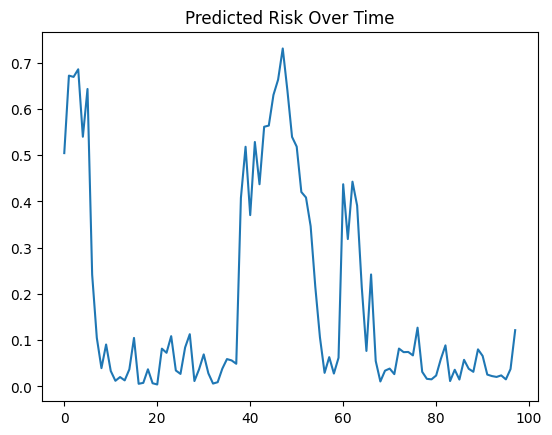

In [21]:
import matplotlib.pyplot as plt

plt.plot(final_pred)
plt.title("Predicted Risk Over Time")
plt.show()

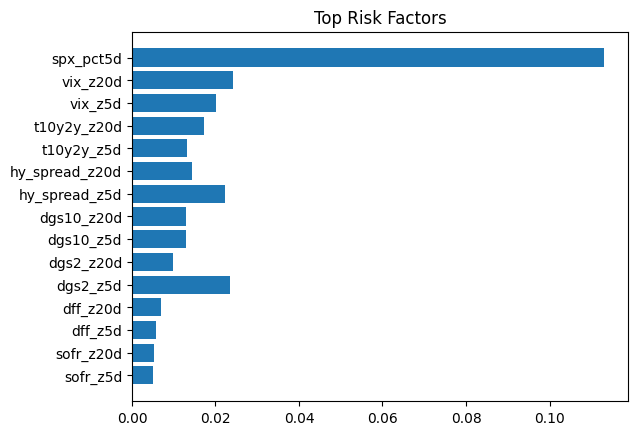

In [22]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

plt.barh(X.columns[:15], importance[:15])
plt.title("Top Risk Factors")
plt.show()

In [23]:
def generate_alert(score):
    if score > 0.7:
        return "🚨 HIGH RISK: Possible crisis"
    elif score > 0.4:
        return "⚠️ MEDIUM RISK: Monitor closely"
    else:
        return "✅ LOW RISK"

alerts = [generate_alert(i) for i in final_pred]

In [24]:
pip install --upgrade typing_extensions

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install --upgrade fastapi pydantic

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install fastapi uvicorn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [27]:
# api.py
from fastapi import FastAPI
import numpy as np

app = FastAPI()

@app.post("/predict")
def predict(data: dict):
    values = np.array(list(data.values())).reshape(1, -1)
    
    pred = xgb.predict(values)[0]
    
    return {
        "risk_score": float(pred),
        "risk_level": "HIGH" if pred > 0.5 else "LOW"
    }

In [28]:
y_test_binary = (y_test > 0.5).astype(int)
y_pred_binary = (xgb_pred > 0.5).astype(int)

In [29]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test_binary, y_pred_binary)
print("F1 Score:", f1)

F1 Score: 0.3157894736842105


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test_binary, y_pred_binary))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93        93
           1       0.25      0.43      0.32         7

    accuracy                           0.87       100
   macro avg       0.60      0.67      0.62       100
weighted avg       0.91      0.87      0.89       100



In [32]:
def risk_class(x):
    if x < 0.2:
        return 0
    elif x < 0.5:
        return 1
    else:
        return 2

y_test_multi = [risk_class(i) for i in y_test]
y_pred_multi = [risk_class(i) for i in xgb_pred]

In [34]:
f1_multi = f1_score(y_test_multi, y_pred_multi, average=None)
print("Multi-class F1:", f1_multi)

Multi-class F1: [0.93055556 0.4        0.46153846]
